Mounted at /content/drive


/tmp/ipykernel_866/1378299947.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Cleaned Date'] = pd.to_datetime('2023-01-01 ' + df['Cleaned Date'].astype(str), errors='coerce')
/tmp/ipykernel_866/1378299947.py:33: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_resampled = df.set_index('Cleaned Date').resample('30S').sum().reset_index()


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 352ms/step - accuracy: 0.5168 - loss: 1.1456 - val_accuracy: 0.6111 - val_loss: 0.9483
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7804 - loss: 0.6507 - val_accuracy: 0.6111 - val_loss: 0.8265
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7202 - loss: 0.6142 - val_accuracy: 0.7222 - val_loss: 0.7483
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7332 - loss: 0.5264 - val_accuracy: 0.9444 - val_loss: 0.6847
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6123 - loss: 0.6213 - val_accuracy: 0.8889 - val_loss: 0.6603
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7208 - loss: 0.4879 - val_accuracy: 0.8889 - val_loss: 0.6464
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7674 - loss: 0.5378 - val_accuracy: 0.7222 - val_loss: 0.6450
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6863 - loss: 0.5303 - val_accuracy: 0.7778 - val_loss

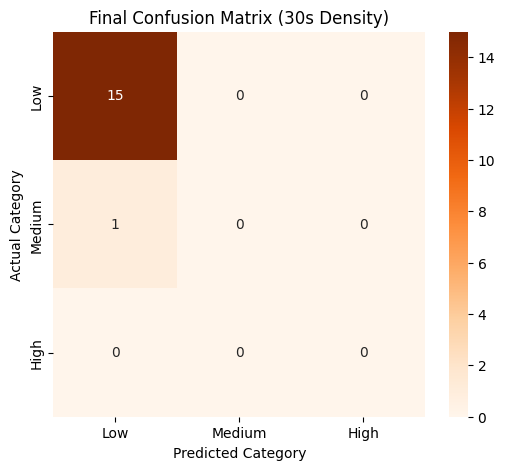

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# ---------------------------------------------------------
# 1. MOUNT DRIVE & LOAD DATA
# ---------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# Ensure the path below matches the location of your file in Drive
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/data tol_v2.xlsx', sheet_name='Cleaned Cell')

# ---------------------------------------------------------
# 2. 30-SECOND DENSITY RESAMPLING
# ---------------------------------------------------------
# Convert time and sort
df['Cleaned Date'] = pd.to_datetime('2023-01-01 ' + df['Cleaned Date'].astype(str), errors='coerce')
df = df.sort_values('Cleaned Date')

# Aggregate to 30-second windows (Summing TOTAL for density)
df_resampled = df.set_index('Cleaned Date').resample('30S').sum().reset_index()

# Recalculate TOTAL for the 30s window based on gates
gate_cols = [c for c in df_resampled.columns if c.lower().startswith('gate')]
if len(gate_cols) > 0:
    df_resampled['TOTAL'] = df_resampled[gate_cols].sum(axis=1)

# --- APPLY SPECIFIC THRESHOLDS ---
def categorize_traffic(total):
    if total <= 8: return 0      # Low
    elif total <= 14: return 1   # Medium
    else: return 2               # High

df_resampled['target'] = df_resampled['TOTAL'].apply(categorize_traffic)

# ---------------------------------------------------------
# 3. FEATURE ENGINEERING
# ---------------------------------------------------------
# Momentum, Trend and Cyclical Time
df_resampled['diff_1'] = df_resampled['TOTAL'].diff(1).fillna(0)
df_resampled['roll_mean_5'] = df_resampled['TOTAL'].rolling(window=5, min_periods=1).mean().shift(1).fillna(0)
df_resampled['roll_std_5'] = df_resampled['TOTAL'].rolling(window=5, min_periods=1).std().shift(1).fillna(0)
df_resampled['minute'] = df_resampled['Cleaned Date'].dt.minute
df_resampled['min_sin'] = np.sin(2 * np.pi * df_resampled['minute'] / 60)
df_resampled['min_cos'] = np.cos(2 * np.pi * df_resampled['minute'] / 60)

feature_cols = ['diff_1', 'roll_mean_5', 'roll_std_5', 'min_sin', 'min_cos'] + gate_cols

# ---------------------------------------------------------
# 4. WINDOWING & SPLITTING
# ---------------------------------------------------------
def make_sequences(features, targets, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(features)):
        Xs.append(features[i-seq_len:i])
        ys.append(targets[i])
    return np.array(Xs), np.array(ys)

seq_len = 10
X_seq, y_seq = make_sequences(df_resampled[feature_cols].values, df_resampled['target'].values, seq_len)

# 80/20 chronological split
split_idx = int(len(X_seq) * 0.8)
X_train_raw, y_train_raw = X_seq[:split_idx], y_seq[:split_idx]
X_test_seq, y_test_seq = X_seq[split_idx:], y_seq[split_idx:]

# ---------------------------------------------------------
# 5. SCALING & BALANCING
# ---------------------------------------------------------
n_samples, s_len, n_features = X_train_raw.shape
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw.reshape(-1, n_features)).reshape(n_samples, s_len, n_features)
X_test_scaled = scaler.transform(X_test_seq.reshape(-1, n_features)).reshape(X_test_seq.shape)

# SMOTE Balancing
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = sm.fit_resample(X_train_reshaped, y_train_raw)

X_train_final = X_train_res.reshape(X_train_res.shape[0], seq_len, n_features)
y_train_final = y_train_res

# ---------------------------------------------------------
# 6. MODEL: BiLSTM-BiGRU HYBRID
# ---------------------------------------------------------
tf.keras.backend.clear_session()
model = keras.Sequential([
    layers.Input(shape=(seq_len, n_features)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4))),
    layers.BatchNormalization(),
    layers.Bidirectional(layers.GRU(32, kernel_regularizer=regularizers.l2(1e-4))),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------------------------------------
# 7. TRAINING & VISUALIZATION
# ---------------------------------------------------------
es = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train_final, y_train_final, validation_split=0.2,
                    epochs=100, batch_size=16, callbacks=[es], verbose=1)

# Predict
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

# CLASSIFICATION REPORT
print("\nClassification Report (8-14 Thresholds):")
print(classification_report(y_test_seq, y_pred, labels=[0, 1, 2],
                            target_names=['Low', 'Medium', 'High'], zero_division=0))

# CONFUSION MATRIX PLOT
cm = confusion_matrix(y_test_seq, y_pred, labels=[0, 1, 2])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title('Final Confusion Matrix (30s Density)')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

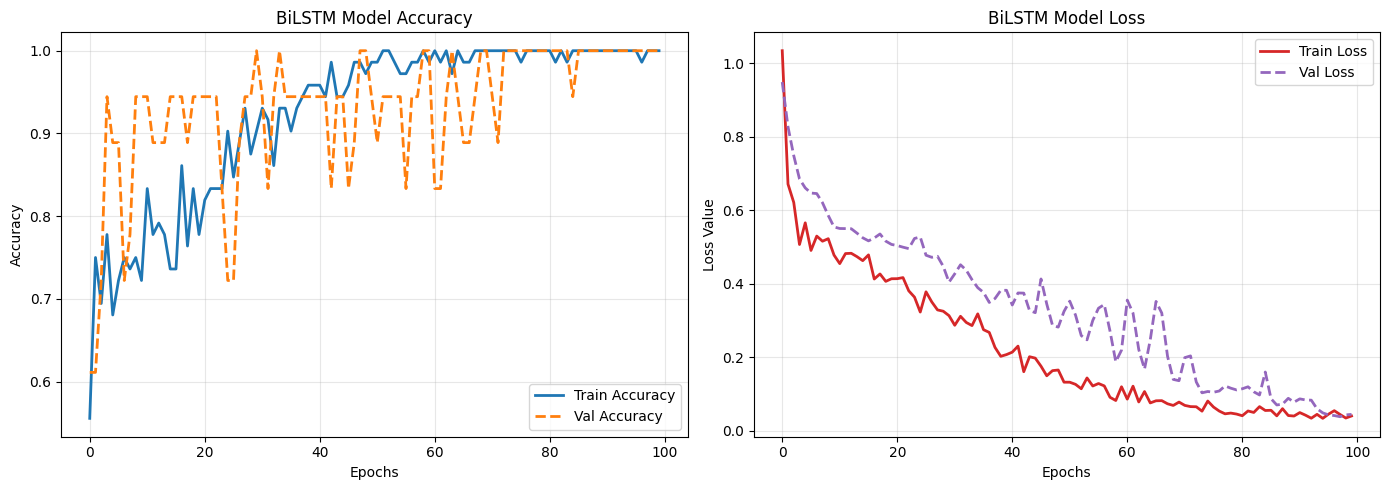

In [10]:
plt.figure(figsize=(14, 5))

# --- 1. Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', linestyle='--', linewidth=2)
# plt.axhline(y=test_acc, color='#2ca02c', linestyle=':', label=f'Test Acc ({test_acc:.4f})')
plt.title('BiLSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# --- 2. Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#d62728', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#9467bd', linestyle='--', linewidth=2)
# plt.axhline(y=test_loss, color='#7f7f7f', linestyle=':', label=f'Test Loss ({test_loss:.4f})')
plt.title('BiLSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ---------------------------------------------------------
# 8. INTERACTIVE UI: PREDICT TRAFFIC AT ANY TIME
# ---------------------------------------------------------

def get_status_info(class_idx):
    """Returns label and color based on class index"""
    mapping = {0: ("LOW", "green"), 1: ("MEDIUM", "orange"), 2: ("HIGH", "red")}
    return mapping.get(class_idx, ("UNKNOWN", "gray"))

def predict_and_plot(time_index):
    # The model needs 'seq_len' amount of history to make a prediction
    if time_index < seq_len:
        print(f"Index {time_index} is too early. Please select an index >= {seq_len} to allow the BiLSTM to see history.")
        return

    # 1. Prepare the sequence for the selected time
    # We take the features from (time_index - seq_len) UP TO (time_index)
    window_data = df_resampled.iloc[time_index - seq_len : time_index][feature_cols].values

    # 2. Scale the window
    window_scaled = scaler.transform(window_data).reshape(1, seq_len, n_features)

    # 3. Use the trained algorithm to predict
    prediction_probs = model.predict(window_scaled, verbose=0)
    predicted_class = np.argmax(prediction_probs)

    # 4. Get the Actual category from the data
    actual_class = df_resampled.iloc[time_index]['target']

    # 5. Format labels
    act_label, act_color = get_status_info(actual_class)
    pred_label, pred_color = get_status_info(predicted_class)

    # 6. Plotting
    plt.figure(figsize=(12, 6))
    current_counts = df_resampled.iloc[time_index][gate_cols]
    bars = plt.bar(gate_cols, current_counts, color=sns.color_palette("viridis", len(gate_cols)), edgecolor='black')

    # Show counts on top of bars
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, int(bar.get_height()),
                 ha='center', fontweight='bold', fontsize=11)

    time_str = df_resampled.iloc[time_index]['Cleaned Date'].strftime('%H:%M:%S')
    plt.title(f"Toll Gate Density Analysis at {time_str}", fontsize=15, pad=20)
    plt.ylabel("Vehicle Count (30s Window)")
    plt.ylim(0, max(df_resampled[gate_cols].max()) + 4)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Draw Actual vs Prediction Badges
    plt.text(0.25, 0.92, f"ACTUAL DATA: {act_label}", transform=plt.gca().transAxes,
             color='white', fontweight='bold', ha='center',
             bbox=dict(facecolor=act_color, alpha=0.8, boxstyle='round,pad=0.5'))

    plt.text(0.75, 0.92, f"ML PREDICTION: {pred_label}", transform=plt.gca().transAxes,
             color='white', fontweight='bold', ha='center',
             bbox=dict(facecolor=pred_color, alpha=0.8, boxstyle='round,pad=0.5'))

    plt.show()

# Create the Interactive Slider
print("\n" + "="*60)
print("INTERACTIVE TRAFFIC PREDICTOR UI")
print("Scroll to select a time interval to see the ML model in action.")
print("="*60)

interact(predict_and_plot,
         time_index=widgets.IntSlider(
             min=seq_len,
             max=len(df_resampled)-1,
             step=1,
             value=seq_len,
             description='Time Index:',
             layout={'width': '600px'},
             continuous_update=False
         ));


INTERACTIVE TRAFFIC PREDICTOR UI
Scroll to select a time interval to see the ML model in action.


interactive(children=(IntSlider(value=10, continuous_update=False, description='Time Index:', layout=Layout(wi…

In [ ]:
# Save the Keras model
model.save('traffic_model.h5')

# Save the scaler (important for processing new data)
import joblib
joblib.dump(scaler, 'scaler.gz')

# Download them to your computer
from google.colab import files
files.download('traffic_model.h5')
files.download('scaler.gz')